<center>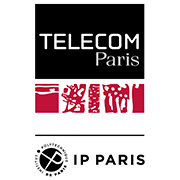</center>

trop long

<h1><center><strong><font color="green">IA 717: CHAI & fairness: linguistics of AI ethics charters & manifestos</font></strong></center></h1>
<h3><center><font color="blue"><strong>Student Version</strong></font></center></h3>

<center>
<h3> Project Supervisor <br/> <a>Maria Boritchev</a></h3>
<email>maria.boritchev@telecom-paris.fr</email>
<br/>

Year 2025-2026
</center>

------------------------

# <font color="green">**Context and objectives**</font>

> The recent years have seen a surge of initiatives with the goal of defining what “ethical” artificial intelligence would or should entail, resulting in the publication of various charters and manifestos discussing AI ethics; these documents originate from academia, AI industry companies, non-profits, regulatory institutions, and the civil society. The contents of such documents vary wildly, from short, vague position statements to verbatims of democratic debates or impact assessment studies. As such, they are a marker of the social world of artificial intelligence, outlining the tenets of different actors, the consensus and dissensus on important goals, and so on. <a href="https://mapaie.telecom-paris.fr/mapaie-paper.pdf">Mapping AI Ethics: a meso-scale analysis of its charters and manifestos, M. Gornet et al, 2024.</a>

The objective of this project to study the linguistic specificities of a corpus of charters and manifestos of AI ethics, called ```MapAIE```. We will study the semantic structure of sentences from MapAIE using the Abstract Meaning Representation (<a href="https://github.com/amrisi/amr-guidelines/blob/master/amr.md">AMR</a>) abstraction method. In particular, we will focus on the usage and the environment of the term _fairness_, in order to see its context and the (possibly different?) meanings associated with its usage.

This project is organised in three subtasks:
1) Data retrieval and exploration.
2) Exploration of the term _fairness_ in the data.
3) AMR graphs exploration & exploration of the term _fairness_ in AMR graphs.


### <font color="green">Evaluation</font>

The project is evaluated through a presentation with a report and your completed project, documented with a README. Grades will be partly individual and partly collective. 

# <font color="green">**1 - Data Presentation and Retrieval**</font>

Our main corpus is called _MapAIE - Mapping AI Ethics_. It is a collection of 436 common charters and manifestos around artificial intelligence and AI ethics. The corpus' <a href="https://mapaie.telecom-paris.fr/mapaie-datasheet.pdf">datasheet</a> provides detailed information about the collection process and the contents of the corpus. 

<font color="red">1.1 Question:</font> Using the git repository https://gitlab.telecom-paris.fr/tiphaine.viard/mapaie, build the data locally. How many documents are there in the ```./pdf``` folder? in the ```./txt``` folder?

In [ ]:
# To-do


<font color="yellow">1.1 Answer:</font>

If the answer in the previous question is different from 436, reduce the local data by keeping only the documents that should be included in the corpus. These documents are identified in the file `all_manifestos.csv`, these are the documents which state `Included`in the column `Status`. 

Let's explore the data. As you can see, documents in ```./pdf``` folder and documents in the ```./txt``` folder are the same, and the name formatting is such that ```n.txt``` contains plain text extracted from ```n.pdf```.

<font color="red">1.2 Question:</font> Why is it useful to have the data both in .pdf and .txt format? Cite one advantage and one drawback for linguistic analysis for each of the formats.

<font color="orange">1.2 Answer:</font> 

We now want to know more about words and key-words used throughout the corpus. There are several terms that are widely used when writing about ethics of AI, and it is interesting from a linguistic point of view to see where and how these words occur. 

<font color="red">1.3 Question:</font> what are the most frequent words, excluding stopwords, in the whole corpus? Please provide visualizations and comment these visualisations.

In [ ]:
# To-do
import os
import math
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import string

nltk.download('punkt')
nltk.download('stopwords')

# Charger tous les documents
folder_path = "mapaie/data/docs"
docs = []
for filename in os.listdir(folder_path):
    filepath = os.path.join(folder_path, filename)
    if os.path.isfile(filepath):
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                text = f.read().strip()
                if text:
                    docs.append(text.lower())
        except:
            pass

# Préparer stopwords et ponctuation 
stop_words = set(stopwords.words('english'))
punct = set(string.punctuation)

# --- Tokenisation nettoyée ---
tokenized_docs = []
for doc in docs:
    words = nltk.word_tokenize(doc)
    words = [w for w in words if w not in stop_words and w not in punct]
    tokenized_docs.append(words)

# --- TF global ---
tf_corpus = Counter()
for doc in tokenized_docs:
    tf_corpus.update(doc)

# --- DF et IDF ---
df_corpus = Counter()
for word in tf_corpus:
    df_corpus[word] = sum(1 for doc in tokenized_docs if word in doc)

N = len(docs)
idf_corpus = {word: math.log2(N / df_corpus[word]) for word in df_corpus}

# --- TF-IDF global ---
tfidf_corpus = {word: tf_corpus[word] * idf_corpus[word] for word in tf_corpus}

# --- Top 20 mots ---
top_words = dict(sorted(tfidf_corpus.items(), key=lambda x: x[1], reverse=True)[:20])

# --- Histogramme ---
plt.figure(figsize=(12,6))
plt.bar(top_words.keys(), top_words.values(), color='skyblue')
plt.title("Top 20 termes TF-IDF du corpus (stopwords et ponctuation retirés)")
plt.xlabel("Termes")
plt.ylabel("Score TF-IDF")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\const\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\const\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<font color="orange">1.3 Answer:</font> 

# <font color="green">**2 - Exploration of the term _fairness_ in the data**</font>


<font color="red">2.1 Question:</font> Draw a visualisation of the amount of times the term _fairness_ is used in a document compared with the total amount of words in a document. Comment this viualisation: what can we observe? What hypothesis can we draw from this observation?

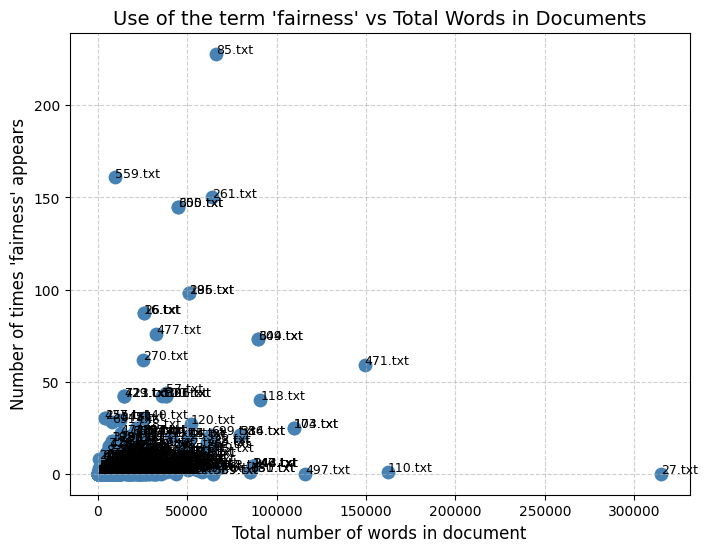

In [2]:
# To-do
import os
import matplotlib.pyplot as plt

# Dossier contenant les fichiers texte (.txt)
folder_path = "docs-20251001T064003Z-1-001/data/txts" 

# Listes pour stocker les données
documents = []
total_words = []
fairness_counts = []

# Lecture de chaque fichier dans le dossier
for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        path = os.path.join(folder_path, filename)
        with open(path, "r", encoding="utf-8") as file:
            text = file.read().lower()
            words = text.split()
            fairness_count = text.count("fairness")
            
            documents.append(filename)
            total_words.append(len(words))
            fairness_counts.append(fairness_count)

# Calcul de la fréquence relative (facultatif)
fairness_ratio = [f / t if t > 0 else 0 for f, t in zip(fairness_counts, total_words)]

# Visualisation
plt.figure(figsize=(8,6))
plt.scatter(total_words, fairness_counts, color='steelblue', s=80)
plt.title("Use of the term 'fairness' vs Total Words in Documents", fontsize=14)
plt.xlabel("Total number of words in document", fontsize=12)
plt.ylabel("Number of times 'fairness' appears", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Ajout d’étiquettes aux points
for i, doc in enumerate(documents):
    plt.annotate(doc, (total_words[i]+50, fairness_counts[i]+0.1), fontsize=9)

plt.show()

<font color="orange">2.1 Answer:</font> 

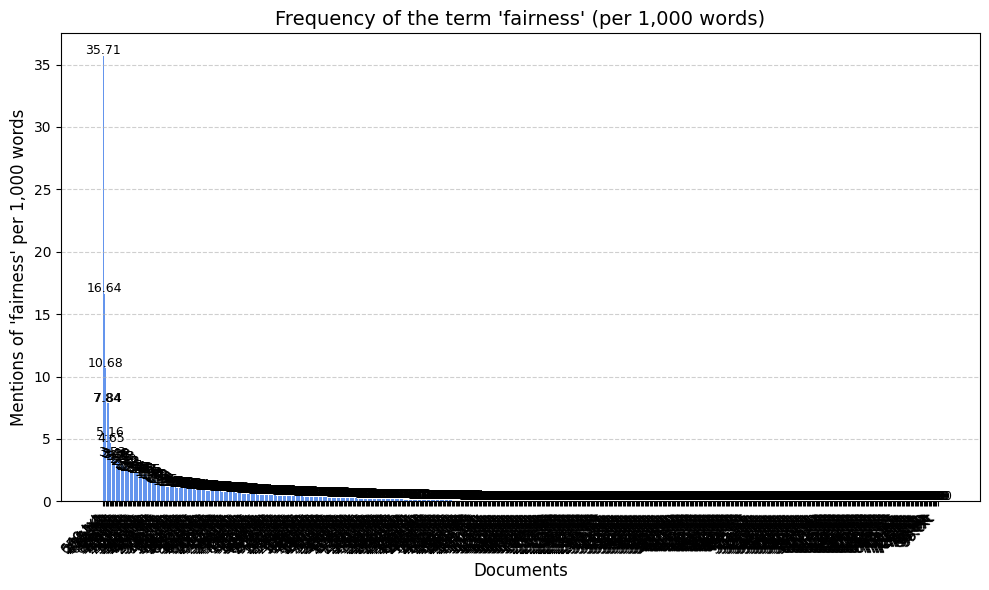

In [5]:
import os
import matplotlib.pyplot as plt

# Dossier contenant les fichiers texte (.txt)
folder_path = "docs-20251001T064003Z-1-001/data/txts"

documents = []
fairness_counts = []
total_words = []
fairness_per_1000 = []

# Lecture des fichiers du corpus
for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        path = os.path.join(folder_path, filename)
        with open(path, "r", encoding="utf-8") as file:
            text = file.read().lower()
            words = text.split()
            fairness_count = text.count("fairness")
            total = len(words)
            
            documents.append(filename)
            fairness_counts.append(fairness_count)
            total_words.append(total)
            fairness_per_1000.append((fairness_count / total) * 1000 if total > 0 else 0)

# Tri par fréquence relative décroissante pour plus de lisibilité
sorted_data = sorted(zip(documents, fairness_per_1000), key=lambda x: x[1], reverse=True)
docs_sorted, freq_sorted = zip(*sorted_data)

# Visualisation (Bar chart)
plt.figure(figsize=(10,6))
bars = plt.bar(docs_sorted, freq_sorted, color="cornflowerblue")
plt.title("Frequency of the term 'fairness' (per 1,000 words)", fontsize=14)
plt.xlabel("Documents", fontsize=12)
plt.ylabel("Mentions of 'fairness' per 1,000 words", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Ajout des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


<font color="red">2.2 Question:</font> which are the documents in which the term _fairness_ appears the most (top 10% of the corpus)? Please provide a visualization and comment it.

In [ ]:
# To-do

<font color="orange">2.2 Answer:</font> 

Now, we want to know more about the context in which the term _fairness_ appears in the corpus. 

<font color="red">2.3 Question:</font> Explore the context in which the term _fairness_ appears in the documents selected in the previous question (top 10% of the corpus). Please provide a visualisation and comment it.

Hint: you could for example consider n-grams containing _fairness_ (but feel free to explore context by other means!)

In [ ]:
# To-do

<font color="orange">2.3 Answer:</font> 

We will now focus on a sentence-level analysis of our corpus and extract a sub-corpus of sentences that use the word _fairness_.

<font color="red">2.4 Question:</font> What information will we lose by focusing on extracted sentences? Please provide three answers.

<font color="orange">2.4 Answer:</font> 

We will definitely loose information, but focusing on a sentence-level analysis gives us access to finer-grained means of linguistic analysis. 

<font color="red">2.5 Question:</font> Extract the _fairness-MapAIE_ corpus: a corpus of sentences of MapAIE containing the term _fairness_. Organise the data in such a way that, for each sentence, we have:
- the textual content of the sentence;
- the identifier (number) of the document this sentence is extracted from.
How many sentences does the _fairness-MapAIE_ corpus contain?

In [ ]:
# To-do

<font color="orange">2.5 Answer:</font> 

In [5]:
!pip install pandas as pd
!pip install blingfire
!pip install openpyxl

ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as



   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [15]:
import os
import re
import pandas as pd
import blingfire as bf

# Dossier contenant les fichiers texte 
txt_folder = "data/txts"

# Liste pour stocker les résultats
fairness_sentences = []

# Parcourir tous les fichiers du dossier
for file_name in os.listdir(txt_folder):
    if not file_name.endswith(".txt"):
        continue

    # Extraire un identifiant du fichier
    doc_id = os.path.splitext(file_name)[0]

    # Lire le contenu du fichier
    file_path = os.path.join(txt_folder, file_name)
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    # Découper en phrases (BlingFire pour éviter les multi-sentences)
    sentences = bf.text_to_sentences(text).split('\n')

    # Ensuite découper encore sur les points si ce n’est pas déjà fait
    final_sentences = []
    # Garder uniquement les phrases contenant "fairness"
    for s in sentences:
        # On split sur le point suivi d’un espace ou fin de chaîne
        parts = re.split(r'\.\s+', s)
        # On ajoute uniquement les parties non vides
        final_sentences.extend([p.strip() + '.' for p in parts if p.strip()])
        if re.search(r"\bfairness\b", s, re.IGNORECASE):
            fairness_sentences.append({"doc_id": doc_id, "sentence": s.strip()})

#  Nettoyer les caractères illégaux pour Excel
def clean_excel_string(s):
    if isinstance(s, str):
        # Supprime tous les caractères de contrôle sauf \n et \t
        return re.sub(r"[\x00-\x08\x0B-\x0C\x0E-\x1F]", "", s)
    return s

# Appliquer à toutes les phrases
fairness_sentences = [
    {"doc_id": fs["doc_id"], "sentence": clean_excel_string(fs["sentence"])}
    for fs in fairness_sentences
]

# Convertir en DataFrame
fairness_df = pd.DataFrame(fairness_sentences)

# Sauvegarder en CSV (plus sûr que Excel pour les caractères spéciaux)
output_file = "fairness_MapAIE.csv"
fairness_df.to_csv(output_file, index=False, encoding="utf-8-sig")

# Résumé
print(f"{len(fairness_df)} phrases contenant 'fairness' ont été trouvées.")
print(f"Résultat exporté dans : {output_file}")

2953 phrases contenant 'fairness' ont été trouvées.
Résultat exporté dans : fairness_MapAIE.csv


In [1]:
!pip install nltk

  Using cached regex-2025.9.18-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 10.0 MB/s  0:00:00
Using cached regex-2025.9.18-cp312-cp312-win_amd64.whl (275 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
 

In [2]:
import nltk
nltk.download('punkt')  # télécharger le modèle une seule fois
from nltk.tokenize import sent_tokenize

# Exemple de texte
text = """
AI ethics is very important. Fairness is one of the key principles.
We must ensure fairness in algorithms. Transparency is also important.
"""

# Découper le texte en phrases
sentences = sent_tokenize(text)

# Filtrer les phrases contenant "fairness"
fairness_sentences = [s for s in sentences if "fairness" in s.lower()]

# Afficher les résultats
print("Toutes les phrases :", sentences)
print("\nPhrases contenant 'fairness' :", fairness_sentences)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\const\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Toutes les phrases : ['\nAI ethics is very important.', 'Fairness is one of the key principles.', 'We must ensure fairness in algorithms.', 'Transparency is also important.']

Phrases contenant 'fairness' : ['Fairness is one of the key principles.', 'We must ensure fairness in algorithms.']


## <font color="red">/!\ To do to get data for the rest of the project /!\ </font> 

### Make sure fairness-MapAIE is properly extracted and available in the project's git repository. Then, send an email to maria.boritchev@telecom-paris.fr to inform me of the availability of fairness-MapAIE so that I can produce data you need for part 3.

We continue by investigating the syntax of sentences. The baseline approach we will use for this part is part-of-speech (POS) tagging: by tagging the elements of sentences by POS, we can investigate the main syntactic roles taken by the term _fairness_.

<font color="red">2.6 Question:</font> What are the syntactic roles taken by the term _fairness_ in the _fairness-MapAIE_ corpus? Please provide a visualization and comment it.

In [ ]:
# To-do

<font color="orange">2.6 Answer:</font> 

# <font color="green">**3 - AMR graphs exploration**</font>


We now investigate the semantics of sentences using Abstract Meaning Representation. Abstract Meaning Representation (AMR, <a href="https://aclanthology.org/W13-2322.pdf">Banarescu et al, 2013</a>)  provides a framework to model the meaning of a sentence, notably actions, events or states and their participants. AMR relies heavily on (verbal) concepts defined in <a href="https://propbank.github.io/">PropBank</a> . The figure below shows an AMR representation for the sentence "Barack Obama was born in 1961". In this figure, ```bear-02``` stands for PropBank's second sense for the verb ''to bear''. Instances are indicated by a following ```/```, for example  ```p``` is an instance of the concept  ```person ```. The names of the variables do not have any particular meaning, they have to be distinct. Relations are indicated by an initial colon (ex:  ```:ARG1```,  ```:time```). Literals (strings and numbers) lack a preceding instance and  ```/``` (ex:  ``` ``Obama'' ``` and  ```1961```. More info on AMR syntax can be found here: https://github.com/amrisi/amr-guidelines/blob/master/amr.md
.

<center>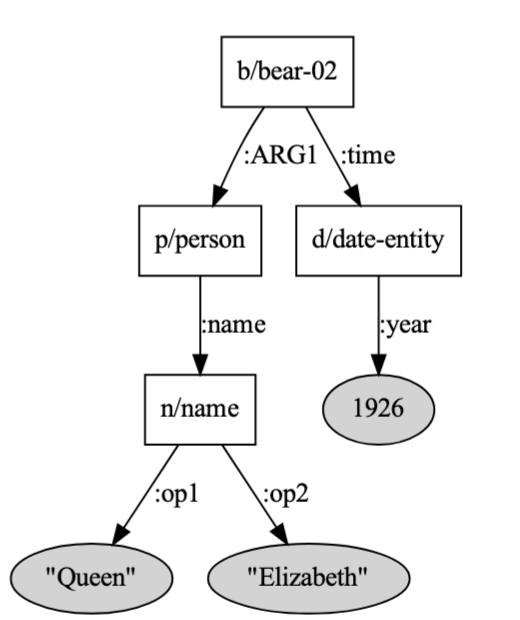</center>

The same graph can be represented in a serialised format called PENMAN format: 
```
(b / bear-02
    :ARG1 (p / person
        :name (n / name
            :op1 "Queen"
            :op2 "Elizabeth"))
    :time (d / date-entity
        :year 1926))
```

AMR graphs for fairness-MapAIE are provided in the file `fairness-MapAIE_penmans.amr`. It is text file containing, for each sentence:
- a line `::snt`, providing the original sentence in English;
- a line with the file number;
- the AMR graph in PENMAN format.

Fairness n'est pas à la racine du graph AMR. A première vue, fairness se trouve à des rangs supérieurs à la racine et est souvent associé à d'autres termes. Nous allons étudier la sémantique de ce terme.

<font color="red">3.1 Question:</font> Explore the PropBank concepts used in the AMR graphs provided in `key_penmans.amr`. What concepts are used to represent the term _fairness_? Which one of these concepts are actually part of PropBank (provide the link to the concept's frame for these)? Which ones are not part of PropBank? Where do these concept come from? 

In [7]:
import re

In [11]:
# To-do
file_path = "fair_AMR-500.amr" 
with open(file_path, "r", encoding="utf-8") as f:
    amr_text = f.read()

# Extraire tous les concepts
# Les concepts AMR sont souvent notés comme : (f / fair-01)
concepts = re.findall(r"/\s*([a-zA-Z0-9\-]+)", amr_text)

# Identifier les concepts PropBank (finissent par -NN) 
propbank_concepts = [c for c in concepts if re.search(r"-\d\d$", c)]
non_propbank_concepts = [c for c in concepts if not re.search(r"-\d\d$", c)]

# Identifier les concepts liés à "fairness"
# On considère "fair" ou "fairness" dans le nom comme indicateur
fairness_propbank = [c for c in propbank_concepts if "fair" in c.lower()]
fairness_non_propbank = [c for c in non_propbank_concepts if "fair" in c.lower()]

print(" Concepts related to FAIRNESS ")
print("PropBank-related:")
for c in sorted(set(fairness_propbank)):
    print(f"• {c}  --> https://verbs.colorado.edu/propbank/framesets-english/{c.split('-')[0]}.html")

print("Non-PropBank-related:")
for c in sorted(set(fairness_non_propbank)):
    print(f"• {c}")

 Concepts related to FAIRNESS 
PropBank-related:
• fair-01  --> https://verbs.colorado.edu/propbank/framesets-english/fair.html
• fairness-01  --> https://verbs.colorado.edu/propbank/framesets-english/fairness.html
Non-PropBank-related:
• ai-fairness-360-attacking-bias-from-all-angles
• fairness
• lawfulness-fairness-and-transparency
• the-perception-of-fairnessof-algorithms-and-proxy-information-in-financial-services
• what-do-we-need-to-do-to-ensure-lawfulness-fairness-and-transparency-in-ai-systems


<font color="orange">3.1 Answer:</font> 

AMR graphs give access to an abstraction of the semantic structure of the original sentences. Here, we are interested in the term _fairness_, its semantic relations, and its semantic role in different contexts. In terms of AMR structure, we want to analyze the following elements:
- the position of the term _fairness_ in the AMR graph (root/node/leaf);
- the parents (superior concepts) of the term _fairness_;
- the siblings (concepts with the same parent) of the term _fairness_;
- the children (inferior concepts) of the term _fairness_;
- the relationships linking _fairness_ to its parents and its children.

<font color="red">3.2 Question:</font> Explore the structure of the AMR graphs provided in `key_penmans.amr`. Please provide visualisations and comments for each of the explored elements.

In [12]:
# To-do
!pip install penman

  Using cached penman-1.3.1-py3-none-any.whl.metadata (7.7 kB)
Using cached penman-1.3.1-py3-none-any.whl (43 kB)


In [2]:
import penman
from penman.models.noop import NoOpModel
import re
from pathlib import Path

# -----------------------------------------------------------
# 1. Read AMR blocks from file (remove comments)
# -----------------------------------------------------------
def read_amr_blocks(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()

    blocks = re.split(r'\n\s*\n', content.strip())
    clean_blocks = []
    for block in blocks:
        lines = [line for line in block.splitlines() if not line.strip().startswith('#')]
        if lines:
            clean_blocks.append('\n'.join(lines))
    return clean_blocks

# -----------------------------------------------------------
# 2. Extract subgraph starting from a given node (DFS)
# -----------------------------------------------------------
def extract_subgraph(graph, subroot):
    visited = set()
    stack = [subroot]
    sub_triples = []
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        for (src, role, tgt) in graph.triples:
            if src == node:
                sub_triples.append((src, role, tgt))
                stack.append(tgt)
    return penman.Graph(sub_triples, top=subroot)

# -----------------------------------------------------------
# 3. Extract only the connected component from a set of triples
# -----------------------------------------------------------
def get_connected_subgraph(triples, top):
    """Keep only triples reachable from top (prevents LayoutError)."""
    visited = set()
    stack = [top]
    connected = []
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        for (src, role, tgt) in triples:
            if src == node:
                connected.append((src, role, tgt))
                stack.append(tgt)
    return connected

# -----------------------------------------------------------
# 4. Split into sentence graphs and remove nested sub-sentences
# -----------------------------------------------------------
def split_all_snt_without_duplicates(amr_str):
    try:
        g = penman.decode(amr_str, model=NoOpModel())
    except Exception as e:
        print(f"[!] Failed to decode AMR:\n{amr_str}\nError: {e}")
        return []

    # Find all :snt* triples anywhere
    snt_triples = [(src, role, tgt) for (src, role, tgt) in g.triples if role.startswith(':snt')]

    if not snt_triples:
        return [penman.encode(g)]

    snt_targets = {tgt for (_, _, tgt) in snt_triples}

    sentences = []
    # 1. Extract all sub-sentences first
    for (_, role, tgt) in snt_triples:
        sub_g = extract_subgraph(g, tgt)
        sentences.append(penman.encode(sub_g))

    # 2. Rebuild parent graph without snt triples
    filtered_triples = [
        t for t in g.triples
        if not (t[1].startswith(':snt') and t[2] in snt_targets)
    ]

    connected_parent_triples = get_connected_subgraph(filtered_triples, g.top)
    if connected_parent_triples:  # Only encode if something remains
        parent_g = penman.Graph(connected_parent_triples, top=g.top)
        sentences.insert(0, penman.encode(parent_g))

    return sentences

# -----------------------------------------------------------
# 5. Filter sentences containing "fairness"
# -----------------------------------------------------------
def filter_fairness(sentences):
    return [s for s in sentences if re.search(r'\bfairness\b', s, re.IGNORECASE)]

# -----------------------------------------------------------
# 6. Main pipeline: read → split → filter → save
# -----------------------------------------------------------
def process_amr_file(input_path, output_path):
    input_path = Path(input_path)
    output_path = Path(output_path)

    blocks = read_amr_blocks(input_path)
    print(f"📥 Found {len(blocks)} AMR blocks in file {input_path}")

    all_sentences = []
    for block in blocks:
        sentences = split_all_snt_without_duplicates(block)
        fairness_sents = filter_fairness(sentences)
        all_sentences.extend(fairness_sents)

    with open(output_path, 'w', encoding='utf-8') as out:
        for s in all_sentences:
            out.write(s.strip() + '\n\n')

    print(f"✅ Wrote {len(all_sentences)} AMRs containing 'fairness' to {output_path}")

# -----------------------------------------------------------
# 7. Run
# -----------------------------------------------------------
if __name__ == "__main__":
    input_file = "fairness-small.amr"
    output_file = "fairness-clean.amr"
    process_amr_file(input_file, output_file)

📥 Found 5 AMR blocks in file fairness-small.amr
✅ Wrote 6 AMRs containing 'fairness' to fairness-clean.amr


In [15]:
import penman

# Étape 1 : Lecture du fichier AMR et nettoyage
file_path = "fair_AMR-500.amr"

with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Conserver uniquement les lignes AMR et les métadonnées (# ::id, # ::snt)
amr_lines = []
for line in lines:
    if line.strip().startswith('(') or line.strip().startswith('#'):
        amr_lines.append(line)

# Réassembler les lignes en un seul texte
amr_text_clean = "".join(amr_lines)

print("Extrait des premières lignes du fichier nettoyé :")
print("\n".join(amr_lines[:10]))

Extrait des premières lignes du fichier nettoyé :
# ::id 0

# ::snt In the ensuing discussion, we note the limitations and assess the implications of this ethical framework for future efforts to create laws, rules, technical standards, and best practices for ethical AI in a wide range of contexts.Keywords: accountability, autonomy, artificial intelligence, beneficence, ethics, explicability, fairness, intelligibility, justice, non-maleficence.1.

(a / and

# ::id 0

# ::snt It also warns against the risk of bias in datasets used to train AI systems, and – unique among the documents – argues for the need to defend against threats to “solidarity,” including “systems of mutual assistance such as in social insurance and healthcare.” Elsewhere ‘justice’ has still other meanings (especially in the sense of fairness), variously relating to the use of AI to correct past wrongs such as eliminating unfair discrimination, promoting diversity, and preventing the rise of new threats to justice.

(m

In [28]:
import penman
blocks = []
current_block = []

with open("fair_AMR-500.amr", "r", encoding="utf-8") as f:
    for line in f:
        if line.strip().startswith("("):
            current_block = [line]
        elif line.strip() == "" and current_block:
            blocks.append("".join(current_block))
            current_block = []
        elif current_block:
            current_block.append(line)
    # ajouter le dernier bloc si nécessaire
    if current_block:
        blocks.append("".join(current_block))

print(f"Nombre de blocs AMR extraits : {len(blocks)}")
graphs = []
for block in blocks:
    try:
        g = penman.decode(block)
        graphs.append(g)
    except penman.DecodeError:
        continue  # ignorer les blocs malformés

print(f"Nombre de graphes AMR valides après nettoyage : {len(graphs)}")

target_concepts = ['fair-01', 'fairness-01']

for i, g in enumerate(graphs):
    # Trouver les triples contenant le concept ciblé
    triples_fairness = [t for t in g.triples if t[2] in target_concepts]
    if triples_fairness:
        print(f"\nGraphe {i+1} contenant fairness")
        # Afficher le texte original si présent
        snt_lines = [line for line in g.metadata.get('snt','').split('\n')]
        if snt_lines:
            print("Texte original :", snt_lines)
        # Afficher les triples pertinents
        print("Triples contenant fairness :")
        for t in triples_fairness:
            print(t)
results = []

for i, g in enumerate(graphs):
    for triple in g.triples:
        if triple[2] in target_concepts:
            results.append({
                "Graphe": i+1,
                "Concept": triple[2],
                "Relation": triple[1],
                "Source": triple[0],
                "Target": triple[2],
                "Texte": g.metadata.get('snt','')
            })

# Afficher un résumé
for r in results:
    print(r)

ignoring epigraph data for duplicate triple: ('a6', ':example', 'n8')
ignoring epigraph data for duplicate triple: ('c6', ':ARG1', 'p7')
ignoring epigraph data for duplicate triple: ('c6', ':ARG1', 'p7')


Nombre de blocs AMR extraits : 500


ignoring epigraph data for duplicate triple: ('a6', ':example', 'n8')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op2', '"Union"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op3', '"Union"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op2', '"Union"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for dup

Nombre de graphes AMR valides après nettoyage : 500

Graphe 1 contenant fairness
Texte original : ['']
Triples contenant fairness :
('f2', ':instance', 'fair-01')

Graphe 2 contenant fairness
Texte original : ['']
Triples contenant fairness :
('f', ':instance', 'fair-01')

Graphe 13 contenant fairness
Texte original : ['']
Triples contenant fairness :
('f', ':instance', 'fair-01')

Graphe 23 contenant fairness
Texte original : ['']
Triples contenant fairness :
('f', ':instance', 'fair-01')

Graphe 34 contenant fairness
Texte original : ['']
Triples contenant fairness :
('f', ':instance', 'fair-01')

Graphe 37 contenant fairness
Texte original : ['']
Triples contenant fairness :
('f2', ':instance', 'fair-01')

Graphe 38 contenant fairness
Texte original : ['']
Triples contenant fairness :
('f2', ':instance', 'fair-01')

Graphe 41 contenant fairness
Texte original : ['']
Triples contenant fairness :
('f', ':instance', 'fair-01')

Graphe 49 contenant fairness
Texte original : ['']
Triples

In [29]:
import penman

file_path = "fair_AMR-500.amr"
valid_graphs = []

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    current_graph = []
    inside_graph = False
    for line in f:
        line = line.strip()
        if not line:
            # fin d'un graphe AMR
            if inside_graph and current_graph:
                try:
                    g = penman.decode("\n".join(current_graph))
                    valid_graphs.append(g)
                except penman.DecodeError:
                    pass  # graphe invalide ignoré
                current_graph = []
                inside_graph = False
            continue

        # Début d'un graphe : doit commencer par '('
        if line.startswith('('):
            inside_graph = True

        if inside_graph:
            current_graph.append(line)

# Vérifier le dernier graphe si nécessaire
if inside_graph and current_graph:
    try:
        g = penman.decode("\n".join(current_graph))
        valid_graphs.append(g)
    except penman.DecodeError:
        pass

print(f"Nombre de graphes AMR valides : {len(valid_graphs)}")

# Filtrer pour 'fair-01' ou 'fairness-01'
target_concepts = {"fair-01", "fairness-01"}
filtered_graphs = [
    g for g in valid_graphs
    if any(triple[2] in target_concepts for triple in g.triples if triple[1] == ":instance")
]

print(f"Nombre de graphes contenant 'fair-01' ou 'fairness-01' : {len(filtered_graphs)}")

ignoring epigraph data for duplicate triple: ('a6', ':example', 'n8')
ignoring epigraph data for duplicate triple: ('c6', ':ARG1', 'p7')
ignoring epigraph data for duplicate triple: ('c6', ':ARG1', 'p7')
ignoring epigraph data for duplicate triple: ('a6', ':example', 'n8')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op2', '"Union"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op3', '"Union"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplica

Nombre de graphes AMR valides : 500
Nombre de graphes contenant 'fair-01' ou 'fairness-01' : 113


In [1]:
import penman

file_path = "fair_AMR-500.amr"
valid_graphs = []

current_graph = []
for line in open(file_path, encoding="utf-8", errors="ignore"):
    line = line.rstrip()

    # Ignorer les métadonnées AMR (# ::id, # ::snt, etc.)
    if line.startswith("#"):
        continue

    # Si c’est une ligne vide -> fin d’un graphe
    if not line.strip():
        if current_graph:
            block = "\n".join(current_graph)
            try:
                g = penman.decode(block)
                valid_graphs.append(g)
            except penman.DecodeError:
                pass
            current_graph = []
        continue

    # Ajouter la ligne courante au graphe
    current_graph.append(line)

# Dernier graphe si nécessaire
if current_graph:
    try:
        g = penman.decode("\n".join(current_graph))
        valid_graphs.append(g)
    except penman.DecodeError:
        pass

print(f"✅ Nombre total de graphes valides : {len(valid_graphs)}")

# Filtrer ceux qui contiennent fair-01 ou fairness-01
target_concepts = {"fair-01", "fairness-01"}
filtered_graphs = [
    g for g in valid_graphs
    if any(t[2] in target_concepts for t in g.triples if t[1] == ":instance")
]

print(f"🎯 Graphes contenant 'fair-01' ou 'fairness-01' : {len(filtered_graphs)}")

ignoring epigraph data for duplicate triple: ('h', ':ARG0', 'n')


✅ Nombre total de graphes valides : 451
🎯 Graphes contenant 'fair-01' ou 'fairness-01' : 100


In [30]:
for i, g in enumerate(filtered_graphs, 1):
    print(f"\n--- Graphe {i} ---")
    for triple in g.triples:
        # Afficher tous les triples où le concept est 'fair-01' ou 'fairness-01'
        if triple[2] in target_concepts or triple[0] in [t[0] for t in g.triples if t[2] in target_concepts]:
            print(triple)


--- Graphe 1 ---
('f2', ':instance', 'fair-01')

--- Graphe 2 ---
('f', ':ARG1', 'd4')
('f', ':instance', 'fair-01')
('f', ':polarity', '-')

--- Graphe 3 ---
('f', ':instance', 'fair-01')

--- Graphe 4 ---
('f', ':instance', 'fair-01')

--- Graphe 5 ---
('f', ':instance', 'fair-01')

--- Graphe 6 ---
('f2', ':instance', 'fair-01')

--- Graphe 7 ---
('f2', ':ARG1', 't2')
('f2', ':instance', 'fair-01')

--- Graphe 8 ---
('f', ':instance', 'fair-01')

--- Graphe 9 ---
('f', ':instance', 'fair-01')
('f', ':mod', 'm')

--- Graphe 10 ---
('f2', ':instance', 'fair-01')
('f2', ':ARG2', 'a2')

--- Graphe 11 ---
('f2', ':instance', 'fair-01')
('f2', ':ARG1', 'm2')
('f2', ':polarity', 'a2')

--- Graphe 12 ---
('f', ':instance', 'fair-01')

--- Graphe 13 ---
('f2', ':ARG1', 't3')
('f2', ':instance', 'fair-01')
('f3', ':ARG1', 't3')
('f3', ':instance', 'fair-01')
('f3', ':polarity', '-')

--- Graphe 14 ---
('f2', ':instance', 'fair-01')
('f2', ':manner', 'm2')

--- Graphe 15 ---
('f', ':instance'

In [18]:
blocks = []
current_block = []

with open("fair_AMR-500.amr", "r", encoding="utf-8") as f:
    for line in f:
        if line.strip().startswith("("):
            current_block = [line]
        elif line.strip() == "" and current_block:
            blocks.append("".join(current_block))
            current_block = []
        elif current_block:
            current_block.append(line)
    # ajouter le dernier bloc si nécessaire
    if current_block:
        blocks.append("".join(current_block))

print(f"Nombre de blocs AMR extraits : {len(blocks)}")

Nombre de blocs AMR extraits : 500


In [20]:
import penman
blocks = []
current_block = []

with open("fair_AMR-500.amr", "r", encoding="utf-8") as f:
    for line in f:
        if line.strip().startswith("("):
            current_block = [line]
        elif line.strip() == "" and current_block:
            blocks.append("".join(current_block))
            current_block = []
        elif current_block:
            current_block.append(line)
    # ajouter le dernier bloc si nécessaire
    if current_block:
        blocks.append("".join(current_block))

print(f"Nombre de blocs AMR extraits : {len(blocks)}")
graphs = []
for block in blocks:
    try:
        g = penman.decode(block)
        graphs.append(g)
    except penman.DecodeError:
        continue  # ignorer les blocs malformés

print(f"Nombre de graphes AMR valides après nettoyage : {len(graphs)}")

ignoring epigraph data for duplicate triple: ('a6', ':example', 'n8')
ignoring epigraph data for duplicate triple: ('c6', ':ARG1', 'p7')
ignoring epigraph data for duplicate triple: ('c6', ':ARG1', 'p7')
ignoring epigraph data for duplicate triple: ('a6', ':example', 'n8')


Nombre de blocs AMR extraits : 500


ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op2', '"Union"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op3', '"Union"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op2', '"Union"')
ignoring epigraph data for duplicate triple: ('m', ':name', 'n')
ignoring epigraph data for duplicate triple: ('m', ':op1', '"European"')
ignoring epigraph data for duplicate triple: ('m', ':op3', '"Union"')
ignoring epigraph data for dup

Nombre de graphes AMR valides après nettoyage : 500


<font color="orange">3.2 Answer:</font> 